In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# covid = pd.read_csv("C:/Users/elzbi/OneDrive/Pulpit/jdszr15-materialy-python/Projekt 2/covid_v1")
covid = pd.read_csv("covid_v1")
df = pd.DataFrame(covid)
covid.sample(30)

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE
74091,0,1,0.0,0.0,0,39,female,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
70512,0,0,NaN,NaN,0,54,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
72499,0,0,NaN,NaN,0,52,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
200637,0,0,NaN,NaN,0,53,female,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
129588,0,0,NaN,NaN,0,28,female,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9389,0,1,NaN,NaN,1,68,female,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
116823,0,1,0.0,0.0,0,54,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
147774,0,0,NaN,NaN,0,42,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
86070,0,1,0.0,0.0,0,61,male,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
192857,1,0,NaN,NaN,0,56,female,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [3]:
covid.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236526 entries, 0 to 236525
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   COVID_TEST_RESULT       236526 non-null  int64  
 1   HOSPITALIZED            236526 non-null  int64  
 2   INTUBED                 131139 non-null  float64
 3   ADMITTED_TO_ICU         130990 non-null  float64
 4   DEAD                    236526 non-null  int64  
 5   AGE                     236526 non-null  int64  
 6   SEX                     236526 non-null  object 
 7   PREGNANT                105069 non-null  float64
 8   SMOKER                  233788 non-null  float64
 9   PNEUMONIA               229339 non-null  float64
 10  COPD                    233997 non-null  float64
 11  ASTHMA                  234020 non-null  float64
 12  IMMUNOSUPPRESSED        233600 non-null  float64
 13  CARDIOVASCULAR_DISEASE  233923 non-null  float64
 14  HIPERTENSION        

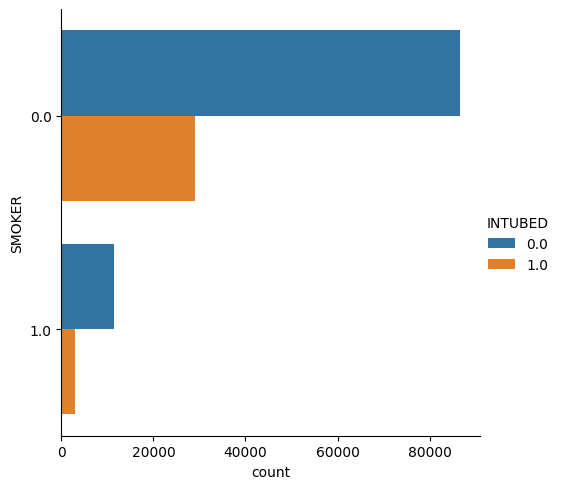

In [4]:
sns.catplot(data=covid, y="SMOKER", hue="INTUBED", kind="count")

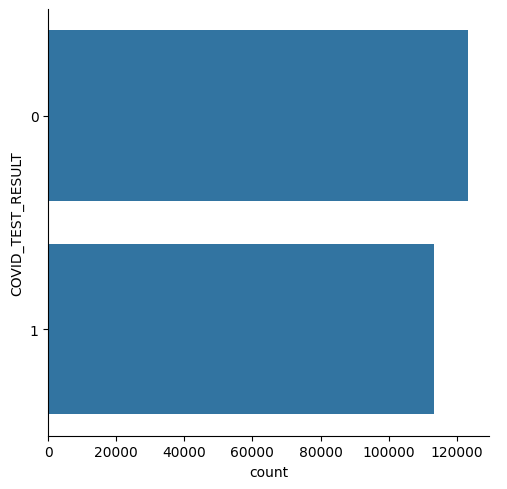

In [5]:
sns.catplot(data=covid, y="COVID_TEST_RESULT", kind="count")

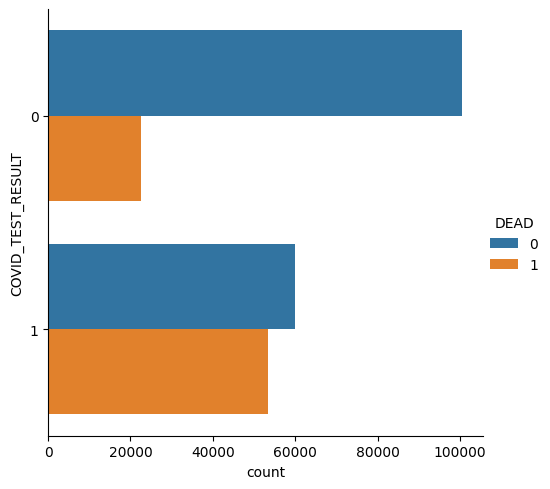

In [6]:
sns.catplot(data=covid, y="COVID_TEST_RESULT", hue="DEAD", kind="count")

In [7]:
covid_positive = covid[covid['COVID_TEST_RESULT'] == 1]
covid_positive.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 113288 entries, 0 to 236025
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   COVID_TEST_RESULT       113288 non-null  int64  
 1   HOSPITALIZED            113288 non-null  int64  
 2   INTUBED                 75002 non-null   float64
 3   ADMITTED_TO_ICU         74994 non-null   float64
 4   DEAD                    113288 non-null  int64  
 5   AGE                     113288 non-null  int64  
 6   SEX                     113288 non-null  object 
 7   PREGNANT                46901 non-null   float64
 8   SMOKER                  112098 non-null  float64
 9   PNEUMONIA               113284 non-null  float64
 10  COPD                    112218 non-null  float64
 11  ASTHMA                  112222 non-null  float64
 12  IMMUNOSUPPRESSED        112083 non-null  float64
 13  CARDIOVASCULAR_DISEASE  112140 non-null  float64
 14  HIPERTENSION            1

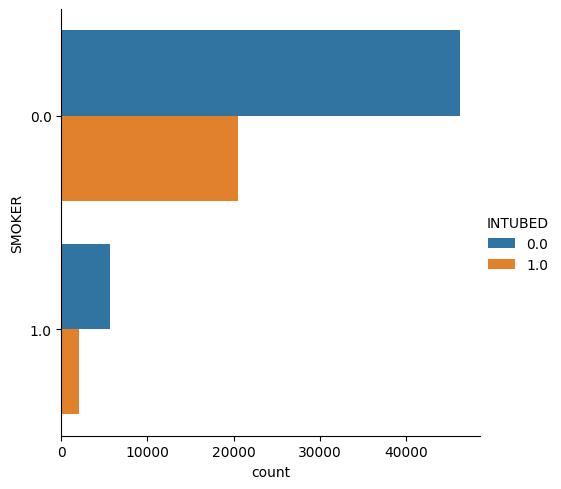

In [8]:
sns.catplot(data=covid_positive, y="SMOKER", hue="INTUBED", kind="count")

In [9]:
# 100% to wszystkie rekordy osób z wynikiem pozytywnym testu na covid
total_counts = len(covid_positive)
percentage_data = covid_positive.groupby("SMOKER")['INTUBED'].value_counts() / total_counts * 100
percentage_data

SMOKER  INTUBED
0.0     0.0        40.788080
        1.0        18.136961
1.0     0.0         4.975814
        1.0         1.765412
Name: count, dtype: float64

In [10]:
# 100% to palacze lub 100% to niepalący - i o to mi chodziło :)
percentage_data = covid_positive.groupby("SMOKER")['INTUBED'].value_counts(normalize=True).mul(100).round(2)
percentage_data

SMOKER  INTUBED
0.0     0.0        69.22
        1.0        30.78
1.0     0.0        73.81
        1.0        26.19
Name: proportion, dtype: float64

In [11]:
percentage_data = percentage_data.reset_index(name='Percentage')


In [12]:
percentage_data

,SMOKER,INTUBED,Percentage
0,0.0,0.0,69.22
1,0.0,1.0,30.78
2,1.0,0.0,73.81
3,1.0,1.0,26.19


<Axes: xlabel='SMOKER', ylabel='Percentage'>

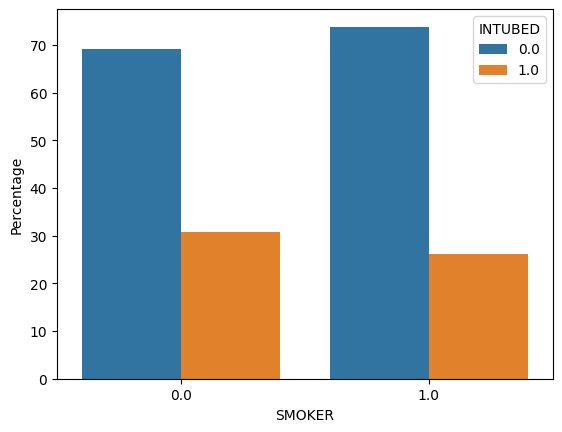

In [13]:
sns.barplot(data=percentage_data, x="SMOKER", y="Percentage", hue="INTUBED")

In [14]:
percentage_data = covid_positive.groupby("SMOKER")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data

SMOKER  HOSPITALIZED
0.0     1               69.23
        0               30.77
1.0     1               56.51
        0               43.49
Name: proportion, dtype: float64

In [15]:
percentage_data = percentage_data.reset_index(name='Percentage')

<Axes: xlabel='SMOKER', ylabel='Percentage'>

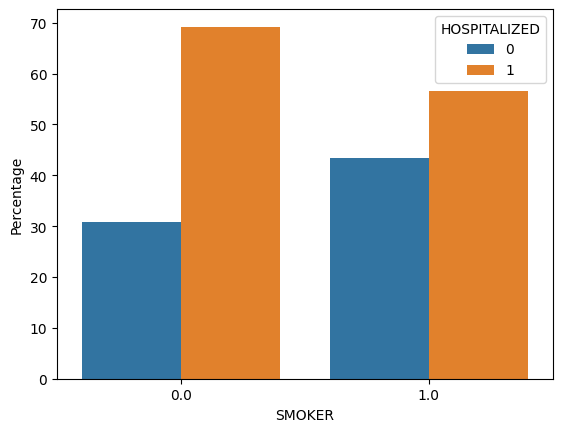

In [16]:
sns.barplot(data=percentage_data, x="SMOKER", y="Percentage", hue="HOSPITALIZED")

<Axes: xlabel='Percentage', ylabel='SMOKER'>

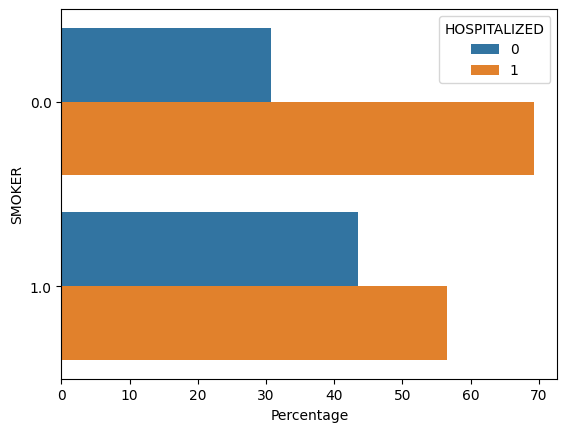

In [17]:
sns.barplot(data=percentage_data, y="SMOKER", x="Percentage", hue="HOSPITALIZED", orient='h')

<Axes: xlabel='Percentage', ylabel='PNEUMONIA'>

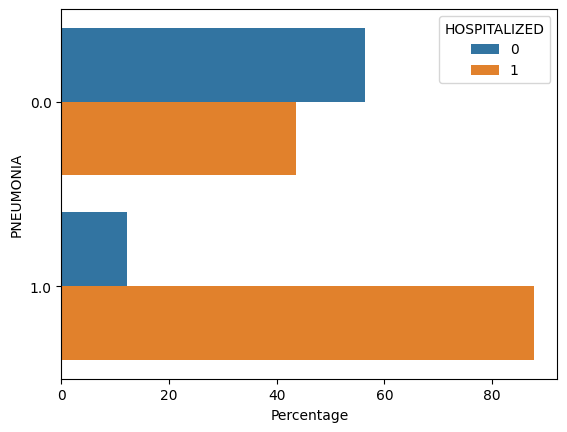

In [18]:
percentage_data = covid_positive.groupby("PNEUMONIA")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="PNEUMONIA", x="Percentage", hue="HOSPITALIZED", orient='h')

<Axes: xlabel='Percentage', ylabel='COPD'>

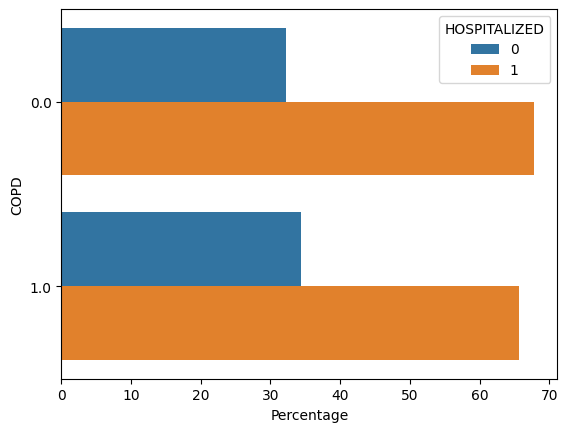

In [19]:
percentage_data = covid_positive.groupby("COPD")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="COPD", x="Percentage", hue="HOSPITALIZED", orient='h')

<Axes: xlabel='Percentage', ylabel='ASTHMA'>

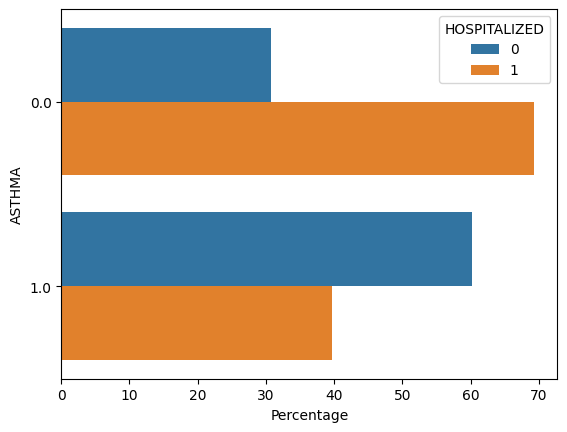

In [20]:
percentage_data = covid_positive.groupby("ASTHMA")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="ASTHMA", x="Percentage", hue="HOSPITALIZED", orient='h')

<Axes: xlabel='Percentage', ylabel='ASTHMA'>

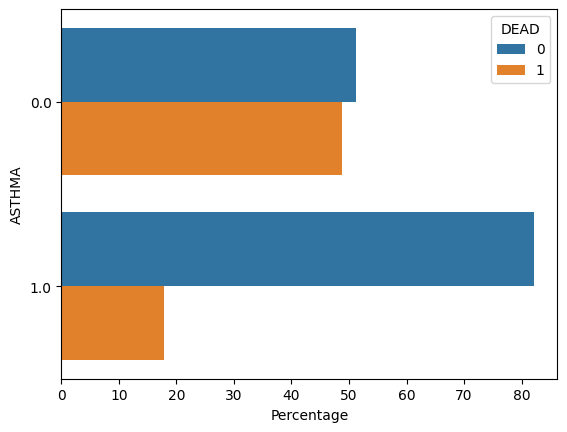

In [21]:
percentage_data = covid_positive.groupby("ASTHMA")['DEAD'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="ASTHMA", x="Percentage", hue="DEAD", orient='h')

<Axes: xlabel='Percentage', ylabel='CARDIOVASCULAR_DISEASE'>

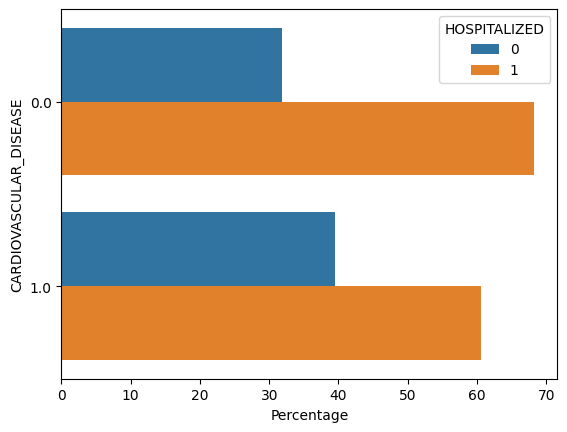

In [22]:
percentage_data = covid_positive.groupby("CARDIOVASCULAR_DISEASE")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="CARDIOVASCULAR_DISEASE", x="Percentage", hue="HOSPITALIZED", orient='h')

<Axes: xlabel='Percentage', ylabel='CARDIOVASCULAR_DISEASE'>

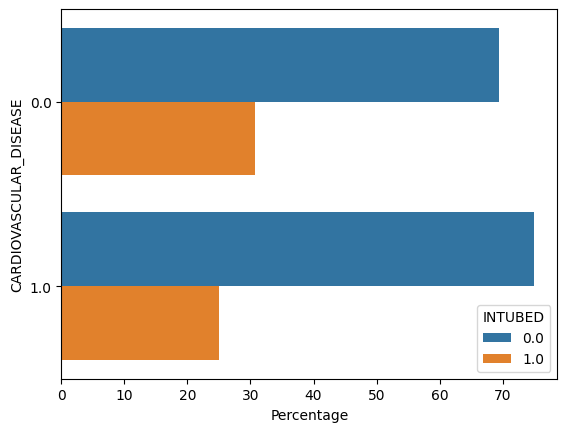

In [23]:
percentage_data = covid_positive.groupby("CARDIOVASCULAR_DISEASE")['INTUBED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="CARDIOVASCULAR_DISEASE", x="Percentage", hue="INTUBED", orient='h')

<Axes: xlabel='Percentage', ylabel='CARDIOVASCULAR_DISEASE'>

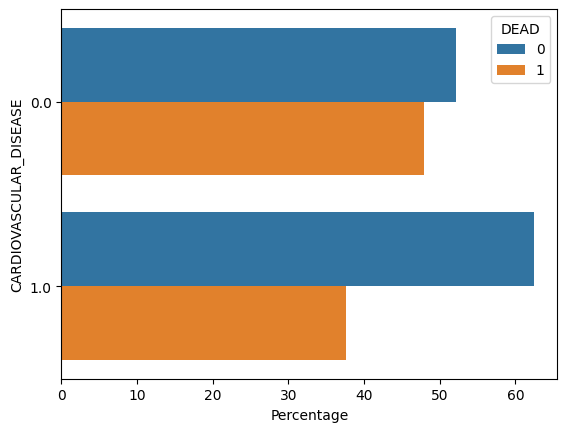

In [24]:
percentage_data = covid_positive.groupby("CARDIOVASCULAR_DISEASE")['DEAD'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="CARDIOVASCULAR_DISEASE", x="Percentage", hue="DEAD", orient='h')

<Axes: xlabel='Percentage', ylabel='OBESITY'>

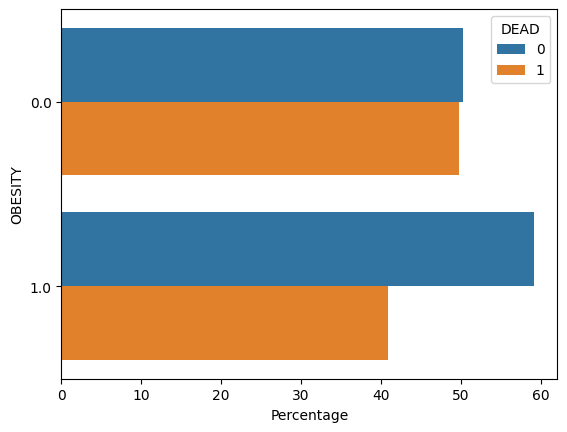

In [25]:
percentage_data = covid_positive.groupby("OBESITY")['DEAD'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="OBESITY", x="Percentage", hue="DEAD", orient='h')

<Axes: xlabel='AGE', ylabel='Count'>

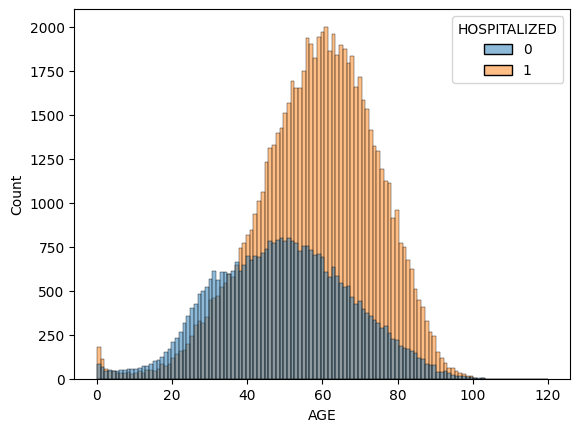

In [26]:
sns.histplot(data=covid_positive, x="AGE", hue="HOSPITALIZED")

<Axes: xlabel='AGE', ylabel='Count'>

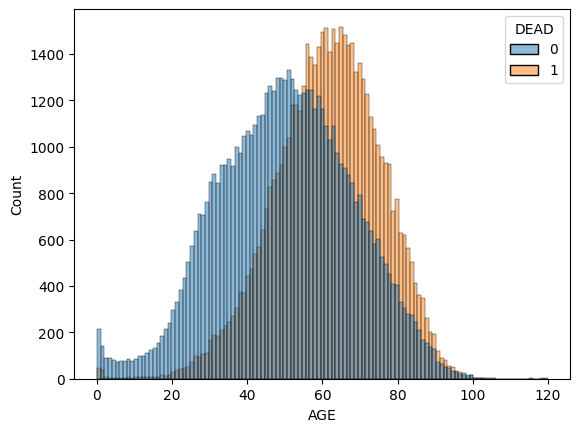

In [27]:
sns.histplot(data=covid_positive, x="AGE", hue="DEAD")

<Axes: xlabel='HOSPITALIZED', ylabel='AGE'>

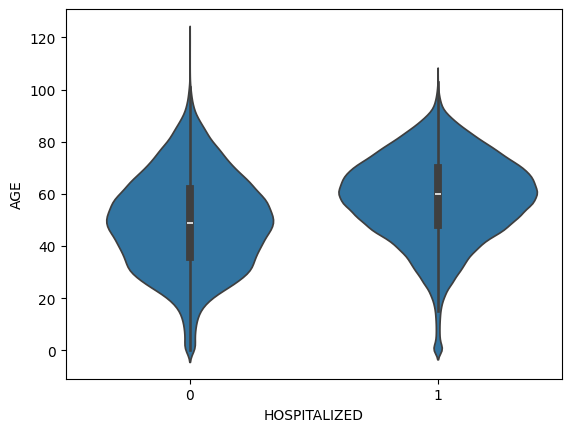

In [28]:
sns.violinplot(data=covid_positive, x="HOSPITALIZED", y="AGE")

<Axes: xlabel='DEAD', ylabel='AGE'>

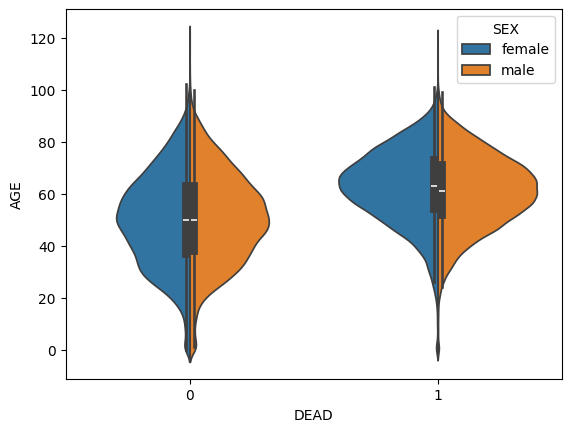

In [29]:
sns.violinplot(data=covid_positive, x="DEAD", y="AGE", hue="SEX", split=True)

<Axes: xlabel='DEAD', ylabel='AGE'>

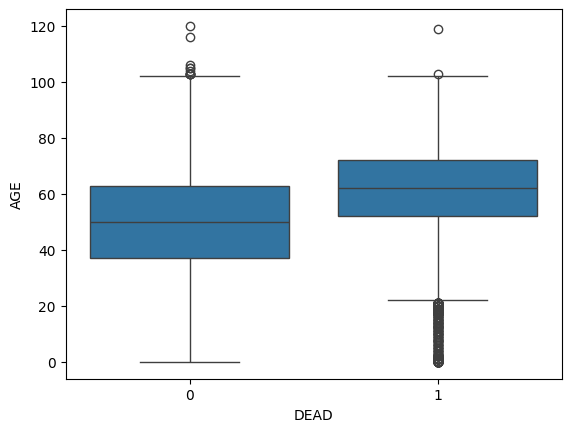

In [30]:
sns.boxplot(data=covid_positive, x="DEAD", y="AGE")

<Axes: xlabel='DEAD', ylabel='AGE'>

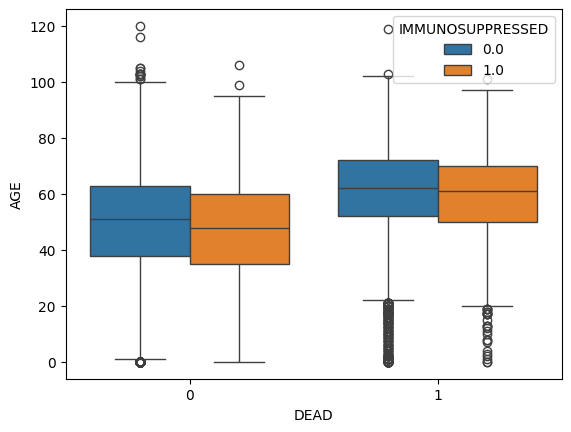

In [31]:
sns.boxplot(data=covid_positive, x="DEAD", y="AGE", hue="IMMUNOSUPPRESSED")

In [32]:
# sns.catplot(data=covid_positive, x="DEAD", y="AGE", kind="swarm")

In [33]:
covid_30 = covid_positive[covid_positive['AGE'] >= 30]
covid_30

,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE
0,1,0,NaN,NaN,1,65,female,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,1,1.0,0.0,1,55,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1,0,NaN,NaN,1,68,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
5,1,1,0.0,0.0,0,40,female,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1,0,NaN,NaN,0,64,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236021,1,0,NaN,NaN,0,67,female,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
236022,1,1,0.0,0.0,0,77,female,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
236023,1,0,NaN,NaN,0,70,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
236024,1,0,NaN,NaN,0,32,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
def tetrachoric_corr(data, col1, col2):
    # Utworzenie tablicy korelacyjnej (ang. contingency table):
    contingency_table = pd.crosstab(data[col1], data[col2])

    # wyciągnicie wartości z tablicy korelacyjnej:
    a = contingency_table.iloc[0,0]
    b = contingency_table.iloc[0,1]
    c = contingency_table.iloc[1,0]
    d = contingency_table.iloc[1,1]

    # obliczenie wsółczynnika:
    tet_corr = math.cos(math.pi / (1 + math.sqrt(a*d /b/c)))
    # print(contingency_table)
    return round(tet_corr,2)

In [51]:
features = ['SMOKER', 'COPD', 'ASTHMA', 'IMMUNOSUPPRESSED', 'CARDIOVASCULAR_DISEASE', 'HIPERTENSION', 'CHRONIC_KIDNEY_DISEASE', 'DIABETES', 'OBESITY', 'OTHER_DISEASE']
result_df = pd.DataFrame(columns=['Feature', 'Tetrachoric Correlation'])

for i in features:
    tet_corr = tetrachoric_corr(covid_30, 'PNEUMONIA', i)
    result_df = pd.concat([result_df, pd.DataFrame({'Feature': [i], 'Tetrachoric Correlation': [tet_corr]})])

print(result_df)

                  Feature  Tetrachoric Correlation
0                  SMOKER                    -0.14
0                    COPD                    -0.09
0                  ASTHMA                    -0.36
0        IMMUNOSUPPRESSED                    -0.17
0  CARDIOVASCULAR_DISEASE                    -0.14
0            HIPERTENSION                     0.01
0  CHRONIC_KIDNEY_DISEASE                    -0.07
0                DIABETES                     0.06
0                 OBESITY                    -0.05
0           OTHER_DISEASE                    -0.19


C:\Users\elzbi\AppData\Local\Temp\ipykernel_13520\3666833052.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, pd.DataFrame({'Feature': [i], 'Tetrachoric Correlation': [tet_corr]})])


<Axes: xlabel='HOSPITALIZED', ylabel='AGE'>

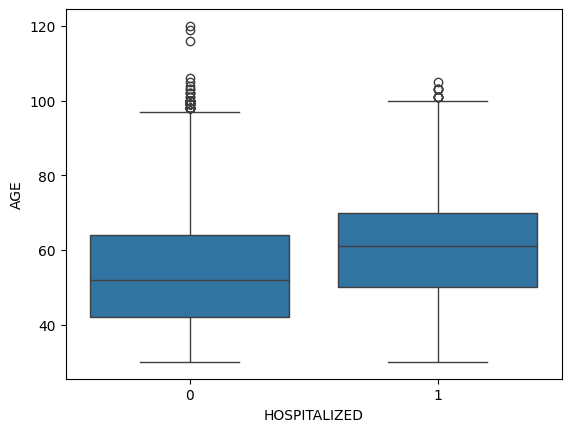

In [35]:
sns.boxplot(data=covid_30, x="HOSPITALIZED", y="AGE")

<Axes: xlabel='AGE', ylabel='Count'>

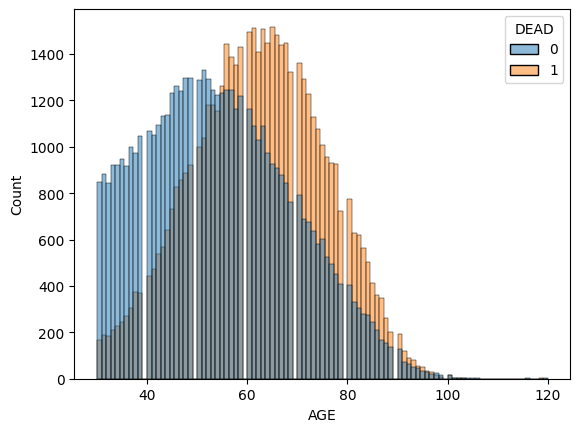

In [36]:
sns.histplot(data=covid_30, x="AGE", hue="DEAD")

In [38]:
percentage_data_30 = covid_30.groupby('SEX')['DEAD'].value_counts(normalize=True).mul(100).round(2)
percentage_data_30 = percentage_data_30.reset_index(name='Percentage')
percentage_data_30

,SEX,DEAD,Percentage
0,female,0,57.32
1,female,1,42.68
2,male,1,55.40
3,male,0,44.60


<Axes: xlabel='Percentage', ylabel='SEX'>

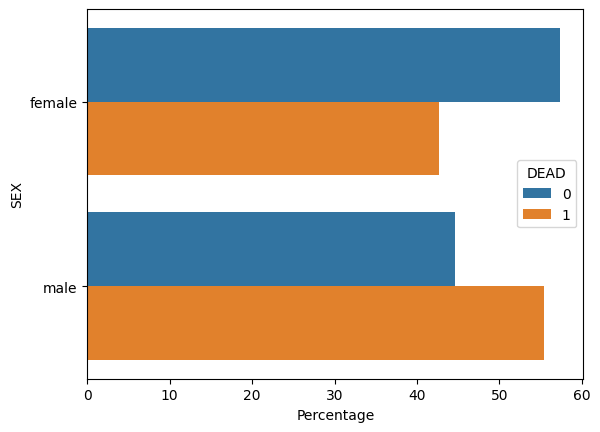

In [39]:
sns.barplot(data=percentage_data_30, y="SEX", x="Percentage", hue="DEAD", orient='h')

<Axes: xlabel='Percentage', ylabel='SEX'>

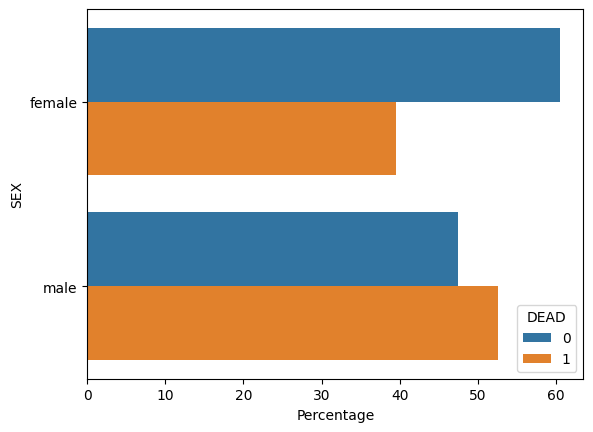

In [40]:
percentage_data = covid_positive.groupby("SEX")['DEAD'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="SEX", x="Percentage", hue="DEAD", orient='h')

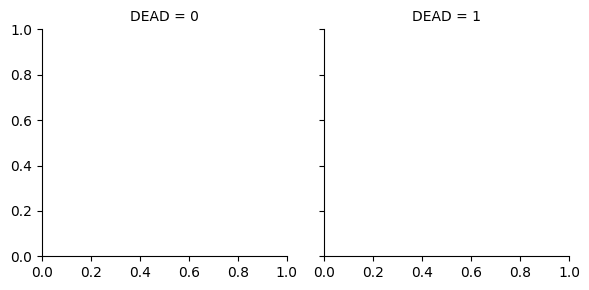

In [41]:
covid_graphs = sns.FacetGrid(covid_positive, col = "DEAD", hue = "HOSPITALIZED")
 



In [42]:
covid_positive['new_column'] = covid_positive(covid_positive['CARDIOVASCULAR_DISEASE'] == 1) & (covid_positive['OBESITY'] == 1)

TypeError: 'DataFrame' object is not callable

In [43]:
covid_positive[obese_heart] = covid_positive[(covid_positive["OBESITY"] == 1) & (covid_positive["CARDIOVASCULAR_DISEASE"] == 1)]

NameError: name 'obese_heart' is not defined

In [44]:
covid3 = covid_positive

In [45]:
covid3['obesity_heart'] = (covid3['OBESITY'] == 1) & (covid3['CARDIOVASCULAR_DISEASE'] == 1)
covid3

C:\Users\elzbi\AppData\Local\Temp\ipykernel_13520\526385152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid3['obesity_heart'] = (covid3['OBESITY'] == 1) & (covid3['CARDIOVASCULAR_DISEASE'] == 1)


,COVID_TEST_RESULT,HOSPITALIZED,INTUBED,ADMITTED_TO_ICU,DEAD,AGE,SEX,PREGNANT,SMOKER,PNEUMONIA,COPD,ASTHMA,IMMUNOSUPPRESSED,CARDIOVASCULAR_DISEASE,HIPERTENSION,CHRONIC_KIDNEY_DISEASE,DIABETES,OBESITY,OTHER_DISEASE,obesity_heart
0,1,0,NaN,NaN,1,65,female,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False
2,1,1,1.0,0.0,1,55,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,False
4,1,0,NaN,NaN,1,68,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,False
5,1,1,0.0,0.0,0,40,female,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
6,1,0,NaN,NaN,0,64,female,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236021,1,0,NaN,NaN,0,67,female,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False
236022,1,1,0.0,0.0,0,77,female,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,False
236023,1,0,NaN,NaN,0,70,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,False
236024,1,0,NaN,NaN,0,32,male,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False


In [ ]:
col=covid1.columns
col

In [ ]:
for column_name in col:
    plt.figure(figsize=(7, 3))
    sns.countplot(data=filtered_covid1, x="DEAD", hue=column_name, palette=['#468499', '#FF7373'])
    plt.title(f'Wpływ {column_name} na śmiertelność z powodu covid', color='black', fontsize=30)
    plt.show()

<Axes: xlabel='Percentage', ylabel='obesity_heart'>

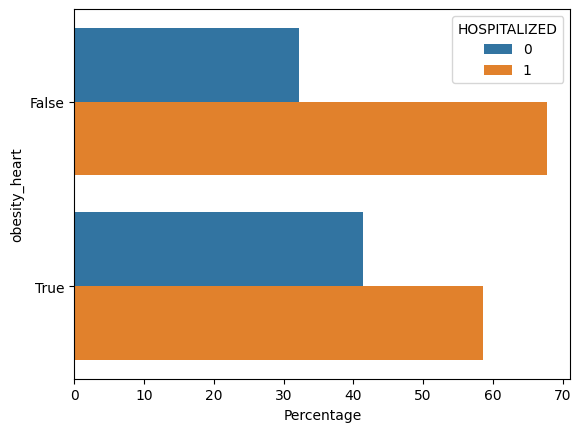

In [ ]:
percentage_data = covid_positive.groupby("obesity_heart")['HOSPITALIZED'].value_counts(normalize=True).mul(100).round(2)
percentage_data = percentage_data.reset_index(name='Percentage')
sns.barplot(data=percentage_data, y="obesity_heart", x="Percentage", hue="HOSPITALIZED", orient='h')